## ***Credit Approval and Loan Credit Analysis***

# ***Author - Vivekanand Mundhe***

# **Objective**


## The Objective of this project is to predict weather a loan applications will be approved based on applicant information such as applicant income, education, employment status, credit history and loan amount.

## **Used Libraries**
* Pandas
* Numpy
* Seaborn
* Matplotlib


# Import Libraries
## Import all required libraries for Data Analysis, Data visualization, and preprocessing

In [102]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import seaborn as sns
import os

In [2]:
df = pd.read_csv('loan_data_new.csv')

### Display:

  * First five rows
  * Dataset shape
  * Data types


# Observation

Brief overview of the dataset and target variable.

In [3]:
df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [4]:
df.rename(columns={"Home Onwership":"Home Ownership"},inplace=True)

In [5]:
df.shape

(45000, 14)

In [6]:
df.dtypes

Age                      int64
Gender                  object
Education               object
Person Income            int64
Employee Experience      int64
Home Ownership          object
Loan Amount              int64
Loan Intent             object
Loan interest Rate     float64
Loan percentage        float64
Credit History           int64
Credit Score             int64
Previous Loan           object
Loan Status              int64
dtype: object

### Check NULL Values

In [7]:
df.isnull().sum()

Age                    0
Gender                 0
Education              0
Person Income          0
Employee Experience    0
Home Ownership         0
Loan Amount            0
Loan Intent            0
Loan interest Rate     0
Loan percentage        0
Credit History         0
Credit Score           0
Previous Loan          0
Loan Status            0
dtype: int64

# ** Data Understanding & Data Cleaning**

## **Overview**

The dataset was examined to understand its structure, data types, summary statistics, and missing values. Numerical and categorical features were identified for further preprocessing.

## **Data Cleaning**

The following preprocessing steps were performed:

* Checked dataset shape and feature information.
* Analyzed summary statistics and missing values.
* Imputed missing values using appropriate techniques:

  * **LoanAmount** → Median
  * **Credit_History** → Mode
  * **Self_Employed** → Mode
* Checked and removed duplicate records (if any).
* Verified data quality before model training.

## **Observation**

* The dataset contained both numerical and categorical features.
* Missing values were successfully handled using median and mode imputation.
* No significant data quality issues remained after preprocessing.
* The cleaned dataset was ready for exploratory analysis and model development.


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  45000 non-null  int64  
 1   Gender               45000 non-null  object 
 2   Education            45000 non-null  object 
 3   Person Income        45000 non-null  int64  
 4   Employee Experience  45000 non-null  int64  
 5   Home Ownership       45000 non-null  object 
 6   Loan Amount          45000 non-null  int64  
 7   Loan Intent          45000 non-null  object 
 8   Loan interest Rate   45000 non-null  float64
 9   Loan percentage      45000 non-null  float64
 10  Credit History       45000 non-null  int64  
 11  Credit Score         45000 non-null  int64  
 12  Previous Loan        45000 non-null  object 
 13  Loan Status          45000 non-null  int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 4.8+ MB


In [9]:
df['Age'].unique()

array([ 22,  21,  25,  23,  24,  26, 144, 123,  20,  32,  34,  29,  33,
        28,  35,  31,  27,  30,  36,  40,  50,  45,  37,  39,  44,  43,
        41,  46,  38,  47,  42,  48,  49,  58,  65,  51,  53,  66,  61,
        54,  57,  59,  62,  60,  55,  52,  64,  70,  78,  69,  56,  73,
        63,  94,  80,  84,  76,  67, 116, 109], dtype=int64)

In [10]:
df['Age']=df['Age'].astype('int64')

In [11]:
df['Age'].head()

0    22
1    21
2    25
3    23
4    24
Name: Age, dtype: int64

In [12]:
df['Loan Amount'] = df['Loan Amount'].astype("int64")

In [13]:
df["Loan Amount"].head()

0    35000
1     1000
2     5500
3    35000
4    35000
Name: Loan Amount, dtype: int64

In [14]:
df["Credit Score"].unique()

array([561, 504, 635, 675, 586, 532, 701, 585, 544, 640, 621, 651, 573,
       708, 583, 670, 663, 694, 709, 679, 684, 662, 691, 600, 654, 626,
       607, 700, 553, 589, 681, 567, 669, 606, 582, 649, 602, 616, 631,
       637, 695, 620, 622, 645, 624, 570, 648, 652, 559, 623, 609, 579,
       688, 661, 562, 664, 564, 598, 557, 677, 690, 599, 604, 601, 634,
       671, 789, 538, 587, 683, 518, 617, 668, 673, 706, 536, 689, 595,
       584, 642, 614, 597, 625, 603, 643, 508, 505, 593, 686, 646, 697,
       615, 687, 650, 588, 658, 531, 665, 703, 594, 618, 574, 577, 653,
       630, 660, 639, 612, 628, 592, 580, 678, 672, 613, 566, 718, 484,
       699, 656, 659, 636, 554, 807, 578, 674, 608, 569, 629, 560, 548,
       667, 676, 581, 655, 551, 529, 666, 576, 633, 611, 657, 647, 542,
       692, 545, 540, 525, 537, 641, 539, 563, 712, 491, 590, 572, 528,
       638, 627, 596, 547, 507, 565, 693, 522, 632, 556, 499, 704, 503,
       714, 552, 555, 558, 521, 605, 571, 591, 719, 610, 535, 64

In [15]:
df[df['Credit Score']<700]['Credit Score'].unique()

array([561, 504, 635, 675, 586, 532, 585, 544, 640, 621, 651, 573, 583,
       670, 663, 694, 679, 684, 662, 691, 600, 654, 626, 607, 553, 589,
       681, 567, 669, 606, 582, 649, 602, 616, 631, 637, 695, 620, 622,
       645, 624, 570, 648, 652, 559, 623, 609, 579, 688, 661, 562, 664,
       564, 598, 557, 677, 690, 599, 604, 601, 634, 671, 538, 587, 683,
       518, 617, 668, 673, 536, 689, 595, 584, 642, 614, 597, 625, 603,
       643, 508, 505, 593, 686, 646, 697, 615, 687, 650, 588, 658, 531,
       665, 594, 618, 574, 577, 653, 630, 660, 639, 612, 628, 592, 580,
       678, 672, 613, 566, 484, 699, 656, 659, 636, 554, 578, 674, 608,
       569, 629, 560, 548, 667, 676, 581, 655, 551, 529, 666, 576, 633,
       611, 657, 647, 542, 692, 545, 540, 525, 537, 641, 539, 563, 491,
       590, 572, 528, 638, 627, 596, 547, 507, 565, 693, 522, 632, 556,
       499, 503, 552, 555, 558, 521, 605, 571, 591, 610, 535, 644, 523,
       546, 534, 682, 447, 680, 568, 524, 619, 460, 696, 527, 51

In [16]:
df[df['Credit Score']<700]['Credit Score'].nunique()

269

In [17]:
df[df['Credit Score']>700]['Credit Score'].unique()

array([701, 708, 709, 789, 706, 703, 718, 807, 712, 704, 714, 719, 702,
       711, 805, 725, 710, 707, 722, 724, 720, 716, 717, 727, 715, 713,
       721, 723, 705, 740, 728, 735, 726, 729, 750, 737, 730, 734, 751,
       739, 736, 738, 733, 732, 731, 741, 748, 744, 762, 742, 745, 743,
       755, 747, 759, 746, 756, 753, 764, 850, 760, 754, 770, 784, 773,
       765, 772, 792, 768, 767], dtype=int64)

In [18]:
df[df['Credit Score']>700]['Credit Score'].nunique()

70

In [19]:
df[df['Credit Score']>750]['Credit Score'].unique()

array([789, 807, 805, 751, 762, 755, 759, 756, 753, 764, 850, 760, 754,
       770, 784, 773, 765, 772, 792, 768, 767], dtype=int64)

In [20]:
df[df['Credit Score']>750]['Credit Score'].nunique()

21

In [21]:
df['Credit History']=df['Credit History'].astype("int64")

In [22]:
df['Credit History'].unique()

array([ 3,  2,  4,  8,  7,  6,  9, 10,  5, 11, 16, 15, 12, 13, 17, 14, 25,
       28, 27, 22, 19, 29, 23, 26, 20, 21, 30, 24, 18], dtype=int64)

In [23]:
df['Credit History'].head()

0    3
1    2
2    3
3    2
4    4
Name: Credit History, dtype: int64

## Check Duplicate Values

In [24]:
df.duplicated().sum()

0

In [25]:
df.describe()

,Age,Person Income,Employee Experience,Loan Amount,Loan interest Rate,Loan percentage,Credit History,Credit Score,Loan Status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [26]:
df.columns

Index(['Age', 'Gender', 'Education', 'Person Income', 'Employee Experience',
       'Home Ownership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate',
       'Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan',
       'Loan Status'],
      dtype='object')

## Check NULL Values

In [27]:
df.isnull().sum()

Age                    0
Gender                 0
Education              0
Person Income          0
Employee Experience    0
Home Ownership         0
Loan Amount            0
Loan Intent            0
Loan interest Rate     0
Loan percentage        0
Credit History         0
Credit Score           0
Previous Loan          0
Loan Status            0
dtype: int64

## Check Unique Values and Value_counts of All Columns.

In [28]:
df['Credit Score'].unique()

array([561, 504, 635, 675, 586, 532, 701, 585, 544, 640, 621, 651, 573,
       708, 583, 670, 663, 694, 709, 679, 684, 662, 691, 600, 654, 626,
       607, 700, 553, 589, 681, 567, 669, 606, 582, 649, 602, 616, 631,
       637, 695, 620, 622, 645, 624, 570, 648, 652, 559, 623, 609, 579,
       688, 661, 562, 664, 564, 598, 557, 677, 690, 599, 604, 601, 634,
       671, 789, 538, 587, 683, 518, 617, 668, 673, 706, 536, 689, 595,
       584, 642, 614, 597, 625, 603, 643, 508, 505, 593, 686, 646, 697,
       615, 687, 650, 588, 658, 531, 665, 703, 594, 618, 574, 577, 653,
       630, 660, 639, 612, 628, 592, 580, 678, 672, 613, 566, 718, 484,
       699, 656, 659, 636, 554, 807, 578, 674, 608, 569, 629, 560, 548,
       667, 676, 581, 655, 551, 529, 666, 576, 633, 611, 657, 647, 542,
       692, 545, 540, 525, 537, 641, 539, 563, 712, 491, 590, 572, 528,
       638, 627, 596, 547, 507, 565, 693, 522, 632, 556, 499, 704, 503,
       714, 552, 555, 558, 521, 605, 571, 591, 719, 610, 535, 64

In [29]:
df['Credit History'].unique()

array([ 3,  2,  4,  8,  7,  6,  9, 10,  5, 11, 16, 15, 12, 13, 17, 14, 25,
       28, 27, 22, 19, 29, 23, 26, 20, 21, 30, 24, 18], dtype=int64)

In [30]:
df['Loan Intent'].value_counts()

Loan Intent
EDUCATION            9153
MEDICAL              8548
VENTURE              7819
PERSONAL             7552
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64

In [31]:
df['Loan Amount'].unique()

array([35000,  1000,  5500, ..., 12229,  2771,  6665], dtype=int64)

In [32]:
df['Loan Status'].value_counts()

Loan Status
0    35000
1    10000
Name: count, dtype: int64

In [33]:
df['Loan percentage'].unique()

array([0.49, 0.08, 0.44, 0.53, 0.19, 0.37, 0.35, 0.13, 0.34, 0.3 , 0.27,
       0.25, 0.05, 0.24, 0.31, 0.26, 0.12, 0.18, 0.21, 0.43, 0.11, 0.4 ,
       0.32, 0.1 , 0.41, 0.22, 0.07, 0.02, 0.17, 0.51, 0.38, 0.33, 0.06,
       0.03, 0.28, 0.04, 0.09, 0.2 , 0.23, 0.15, 0.48, 0.5 , 0.14, 0.42,
       0.01, 0.46, 0.29, 0.39, 0.36, 0.16, 0.  , 0.57, 0.45, 0.52, 0.55,
       0.61, 0.62, 0.66, 0.54, 0.47, 0.56, 0.58, 0.63, 0.59])

In [34]:
df['Loan interest Rate'].unique()

array([16.02, 11.14, 12.87, ..., 19.11, 19.8 , 16.92])

In [35]:
df['Home Ownership'].value_counts()

Home Ownership
RENT        23443
MORTGAGE    18489
OWN          2951
OTHER         117
Name: count, dtype: int64

In [36]:
df['Education'].value_counts()

Education
Bachelor       13399
Associate      12028
High School    11972
Master          6980
Doctorate        621
Name: count, dtype: int64

In [37]:
df['Age'].unique()

array([ 22,  21,  25,  23,  24,  26, 144, 123,  20,  32,  34,  29,  33,
        28,  35,  31,  27,  30,  36,  40,  50,  45,  37,  39,  44,  43,
        41,  46,  38,  47,  42,  48,  49,  58,  65,  51,  53,  66,  61,
        54,  57,  59,  62,  60,  55,  52,  64,  70,  78,  69,  56,  73,
        63,  94,  80,  84,  76,  67, 116, 109], dtype=int64)

## **Exploratory Data Analysis (EDA)**

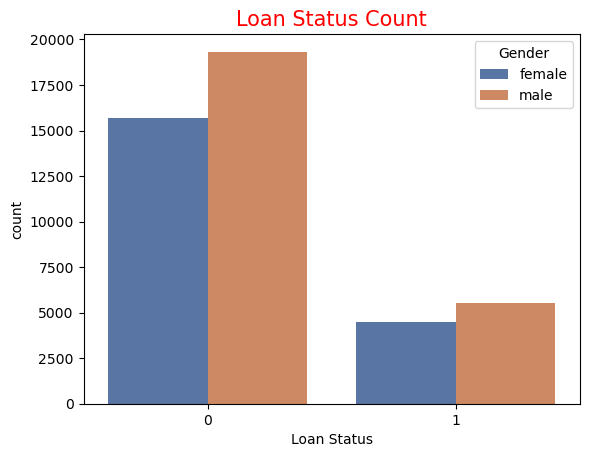

In [38]:
sns.countplot(data=df, x='Loan Status', hue = "Gender",palette="deep")
plt.title("Loan Status Count",color='red',fontsize=15)
plt.show()

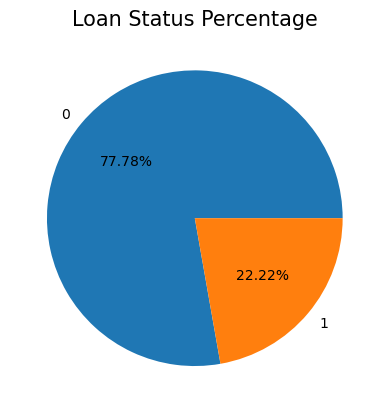

In [39]:
plt.pie(df['Loan Status'].value_counts(),labels=df['Loan Status'].value_counts().index,autopct='%1.2f%%')
plt.title("Loan Status Percentage",color='black',fontsize=15)
plt.show()

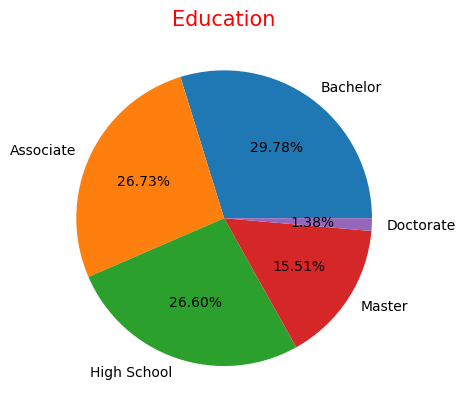

In [40]:
plt.pie(df['Education'].value_counts(),labels=df['Education'].value_counts().index,autopct='%1.2f%%')
plt.title("Education",color='red',fontsize=15)
plt.show()

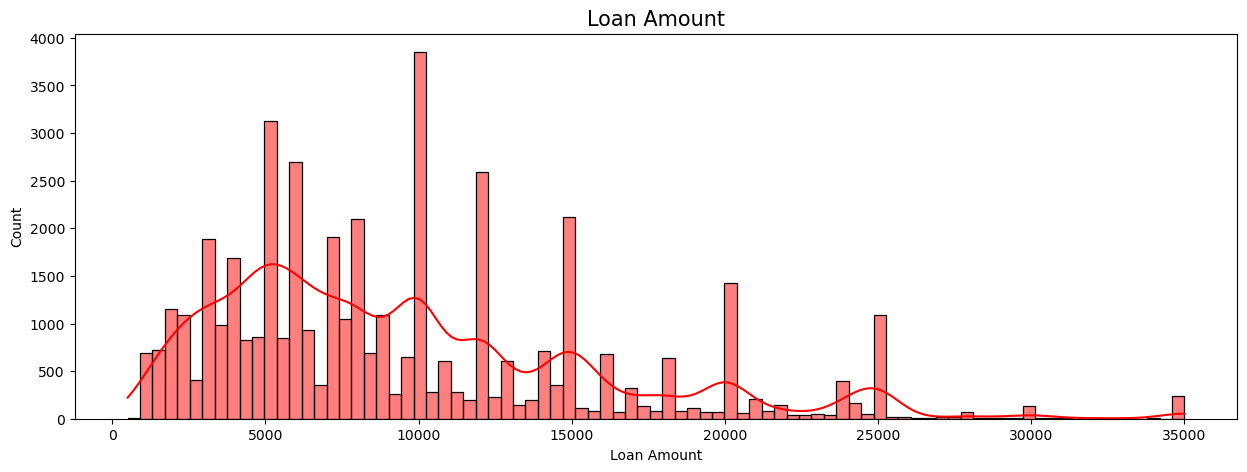

In [41]:
plt.figure(figsize=(15,5))

sns.histplot(data=df,x='Loan Amount',kde=True,color='red')
plt.title("Loan Amount",color='black',fontsize=15)
plt.show()

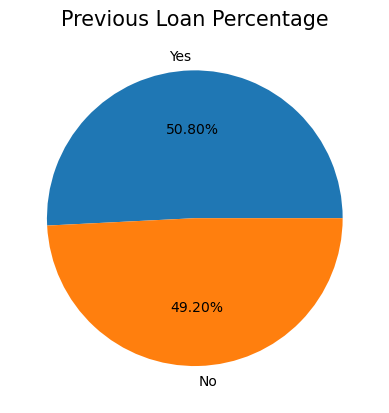

In [42]:
plt.pie(df['Previous Loan'].value_counts(),labels=df['Previous Loan'].value_counts().index,autopct='%1.2f%%')
plt.title("Previous Loan Percentage",color='black',fontsize=15)
plt.show()

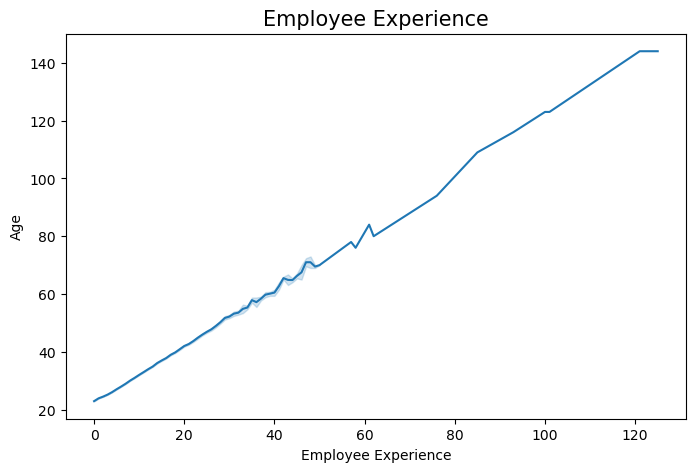

In [55]:
plt.figure(figsize=(8,5))
sns.lineplot(data=df,x="Employee Experience",y='Age')
plt.title("Employee Experience",color='black',fontsize=15)
plt.show()

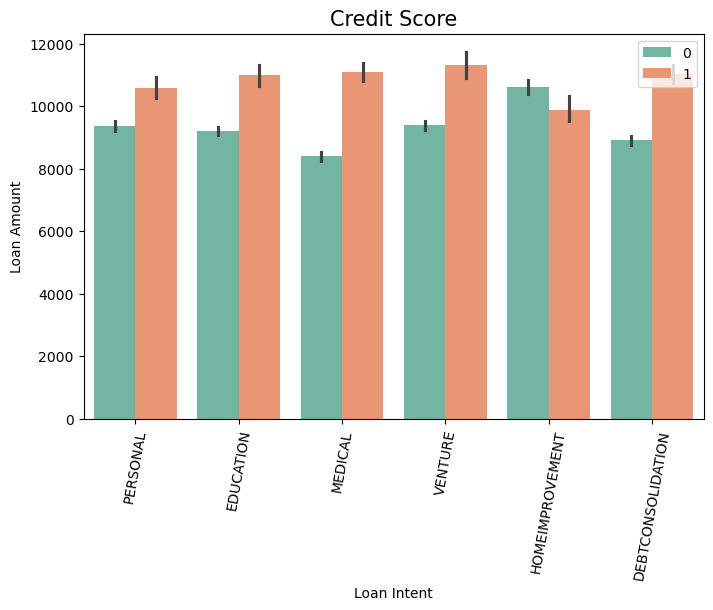

In [54]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x='Loan Intent',y='Loan Amount',hue='Loan Status',palette='Set2')
plt.title("Credit Score",color='black',fontsize=15)
plt.xticks(rotation=80)
plt.legend(loc='upper right')
plt.show()

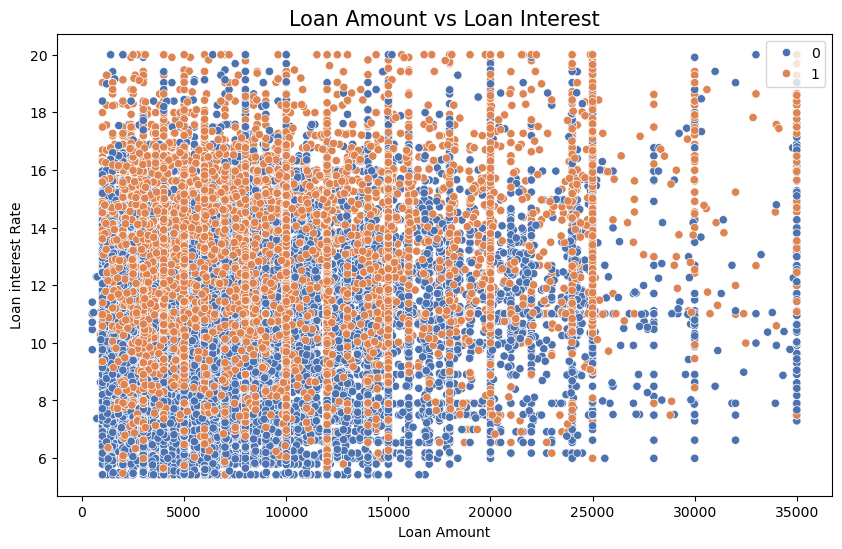

In [75]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x="Loan Amount",y="Loan interest Rate",hue='Loan Status',palette='deep')
plt.title("Loan Amount vs Loan Interest",color='black',fontsize=15)
plt.legend(loc='upper right')
plt.show()

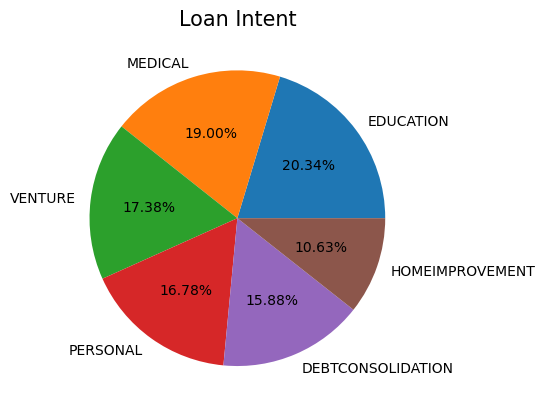

In [76]:
plt.pie(df['Loan Intent'].value_counts(),labels=df['Loan Intent'].value_counts().index,autopct='%1.2f%%')
plt.title("Loan Intent",color='black',fontsize=15)
plt.show()

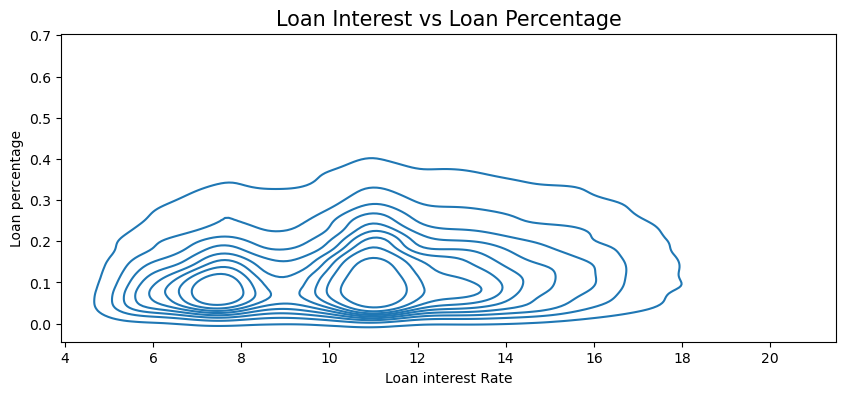

In [83]:
plt.figure(figsize=(10,4))
sns.kdeplot(data=df,x='Loan interest Rate',y='Loan percentage')
plt.title("Loan Interest vs Loan Percentage",color='black',fontsize=15)
plt.show()

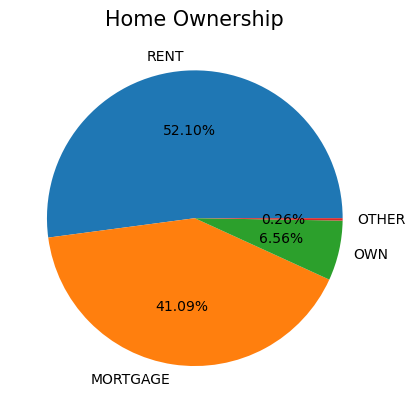

In [87]:
plt.pie(df['Home Ownership'].value_counts(),labels=df['Home Ownership'].value_counts().index,autopct='%1.2f%%')
plt.title('Home Ownership',color='black',fontsize=15)
plt.show()

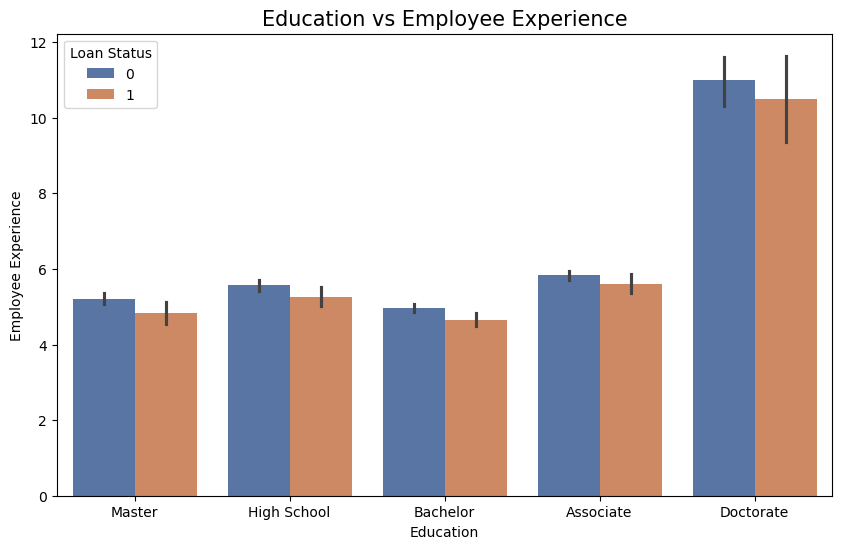

In [95]:
plt.figure(figsize=(10,6))

sns.barplot(data=df,y='Employee Experience',x='Education',hue='Loan Status',palette='deep')
plt.title("Education vs Employee Experience",color='black',fontsize=15)
plt.show()

In [96]:
df.corr(numeric_only=True)

,Age,Person Income,Employee Experience,Loan Amount,Loan interest Rate,Loan percentage,Credit History,Credit Score,Loan Status
Age,1.000000,0.193698,0.954412,0.050750,0.013402,-0.043299,0.861985,0.178432,-0.021476
Person Income,0.193698,1.000000,0.185987,0.242290,0.001510,-0.234177,0.124316,0.035919,-0.135808
Employee Experience,0.954412,0.185987,1.000000,0.044589,0.016631,-0.039862,0.824272,0.186196,-0.020481
Loan Amount,0.050750,0.242290,0.044589,1.000000,0.146093,0.593011,0.042969,0.009074,0.107714
Loan interest Rate,0.013402,0.001510,0.016631,0.146093,1.000000,0.125209,0.018008,0.011498,0.332005
Loan percentage,-0.043299,-0.234177,-0.039862,0.593011,0.125209,1.000000,-0.031868,-0.011483,0.384880
Credit History,0.861985,0.124316,0.824272,0.042969,0.018008,-0.031868,1.000000,0.155204,-0.014851
Credit Score,0.178432,0.035919,0.186196,0.009074,0.011498,-0.011483,0.155204,1.000000,-0.007647
Loan Status,-0.021476,-0.135808,-0.020481,0.107714,0.332005,0.384880,-0.014851,-0.007647,1.000000


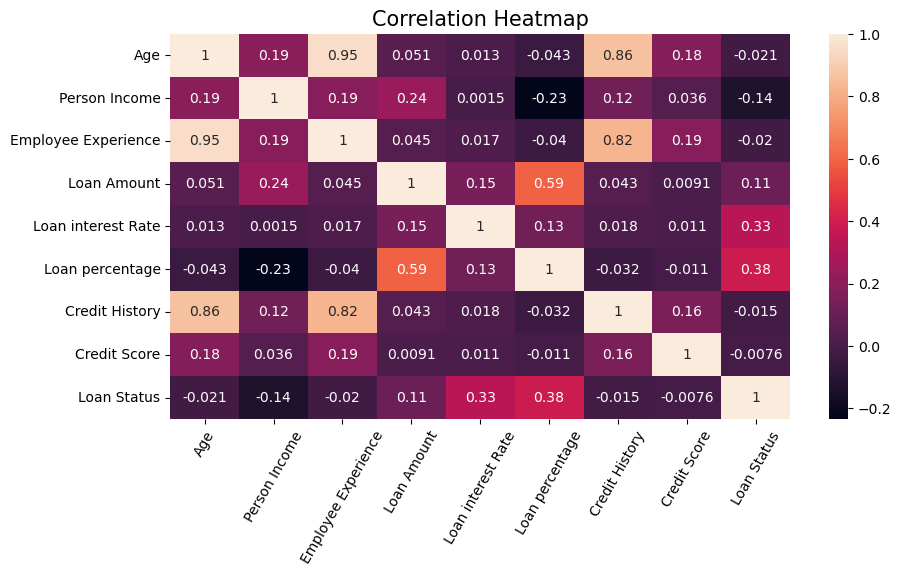

In [99]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title("Correlation Heatmap",color='black',fontsize=15)
plt.xticks(rotation=60)
plt.show()

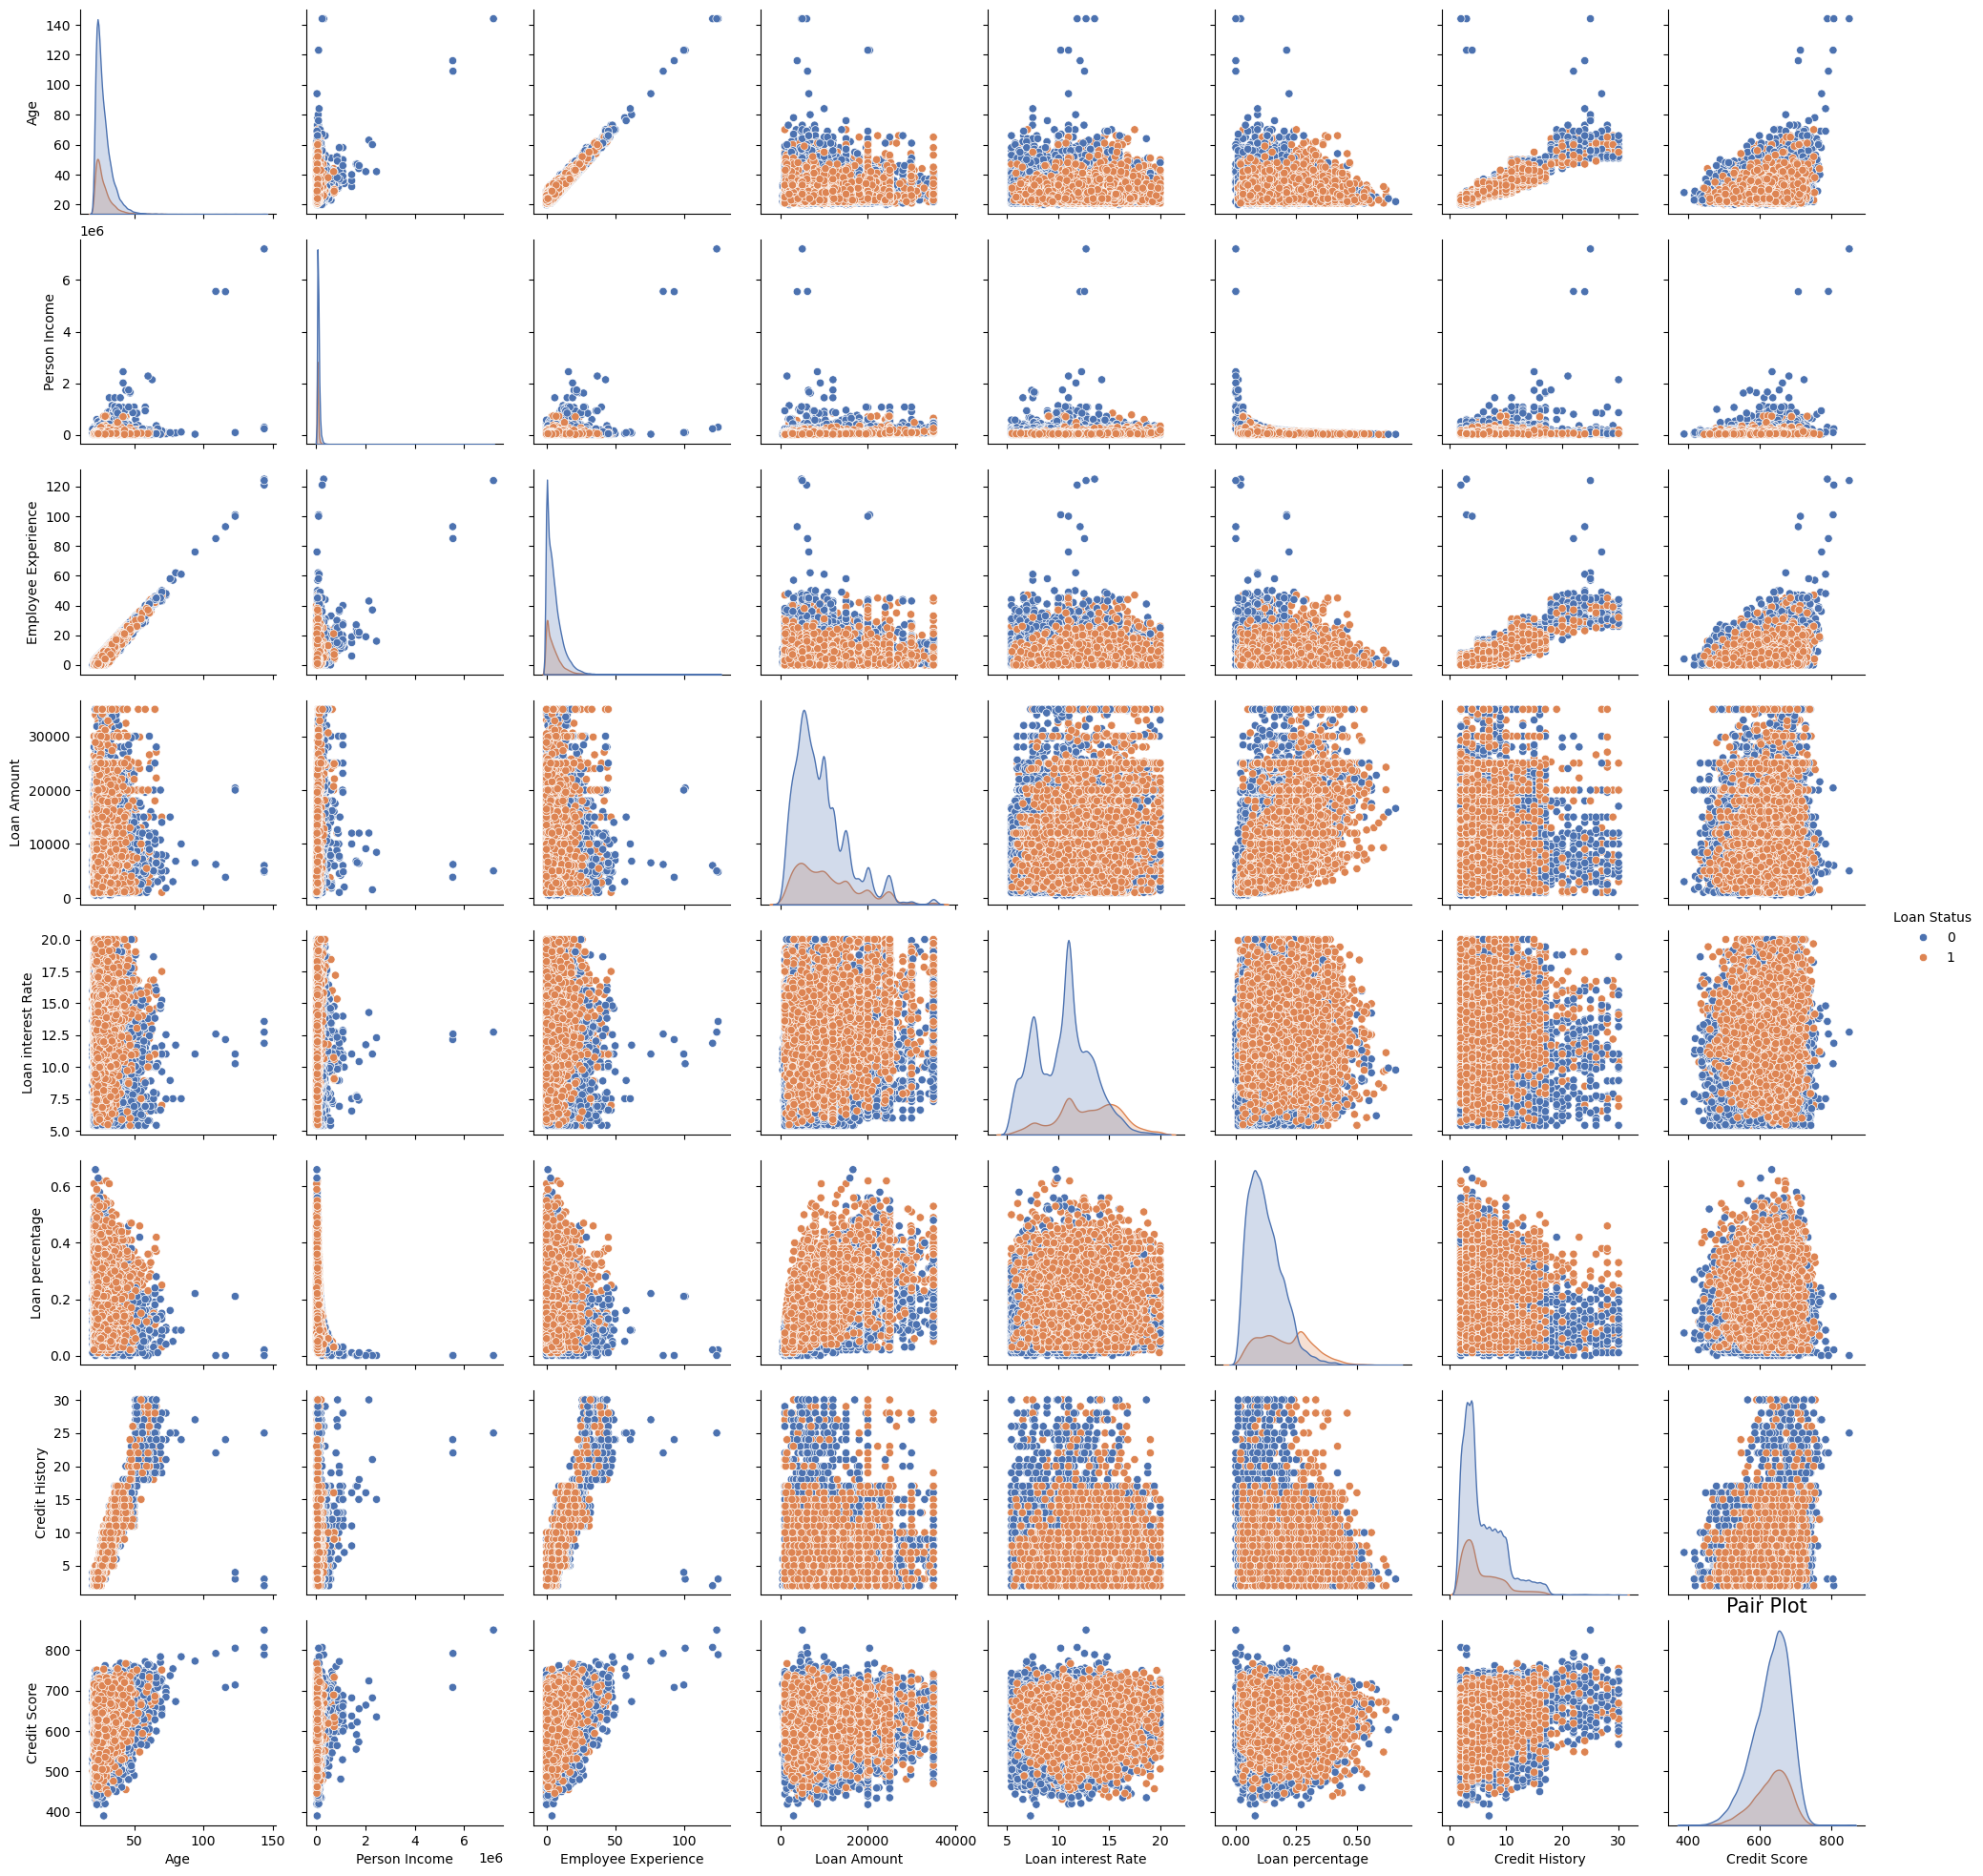

In [100]:
sns.pairplot(data=df,hue="Loan Status",palette='deep')
plt.title("Pair Plot",color='black',fontsize=15)
plt.show()

In [101]:
df.to_csv("Loan_data_new.csv",index=False)